<a href="https://colab.research.google.com/github/muhammedriswanp/ai-ml-learning-lab/blob/main/WEEK6_AI_Agent_Orchestration_Frameworks/LangGraph_Fundamentals.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Claims Intake Agent using LangGraph

## Step 1 — Install Required Libraries

In this notebook, build a complete Claims Intake Agent using LangGraph.

This first cell installs all required libraries.

### Libraries

- langgraph → Graph workflow engine
- langchain → LLM ecosystem
- typing_extensions → Typed state definitions
- pandas → Mock dataset handling


In [1]:

from langgraph.graph import StateGraph, START, END


In [2]:
import pandas as pd
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# Create a Mock Insurance Claims Dataset

Claims Intake Agent needs customer claim records to process.

create a small mock insurance dataset with intentionally missing
information.

- Mandatory field validation
- Missing information detection
- Retry loop
- Final verification

Dataset Columns

- Customer Name
- Policy Number
- Claim Amount
- Claim Type
- Supporting Documents

Some records intentionally contain missing values to simulate real-world scenarios.

In [3]:
claims_data = [
    {
        "customer_name": "Alice",
        "policy_number": "POL1001",
        "claim_amount": 5000,
        "claim_type": "Medical",
        "supporting_documents": ["hospital_bill.pdf"]
    },
    {
        "customer_name": "Bob",
        "policy_number": "",
        "claim_amount": 12000,
        "claim_type": "Vehicle",
        "supporting_documents": ["accident_photo.jpg"]
    },
    {
        "customer_name": "Charlie",
        "policy_number": "POL1003",
        "claim_amount": None,
        "claim_type": "Home",
        "supporting_documents": ["damage_photo.jpg"]
    },
    {
        "customer_name": "David",
        "policy_number": "POL1004",
        "claim_amount": 8000,
        "claim_type": "",
        "supporting_documents": ["invoice.pdf"]
    },
    {
        "customer_name": "Eva",
        "policy_number": "POL1005",
        "claim_amount": 15000,
        "claim_type": "Medical",
        "supporting_documents": []
    },
    {
        "customer_name": "Frank",
        "policy_number": "POL1006",
        "claim_amount": 7000,
        "claim_type": "Travel",
        "supporting_documents": ["ticket.pdf"]
    },
    {
        "customer_name": "Grace",
        "policy_number": "",
        "claim_amount": None,
        "claim_type": "Medical",
        "supporting_documents": []
    },
    {
        "customer_name": "Henry",
        "policy_number": "POL1008",
        "claim_amount": 3000,
        "claim_type": "Vehicle",
        "supporting_documents": ["repair_bill.pdf"]
    },
    {
        "customer_name": "Ivy",
        "policy_number": "POL1009",
        "claim_amount": 22000,
        "claim_type": "Home",
        "supporting_documents": []
    },
    {
        "customer_name": "Jack",
        "policy_number": "",
        "claim_amount": 9000,
        "claim_type": "",
        "supporting_documents": []
    }
]

df = pd.DataFrame(claims_data)

df

,customer_name,policy_number,claim_amount,claim_type,supporting_documents
0,Alice,POL1001,5000.0,Medical,[hospital_bill.pdf]
1,Bob,,12000.0,Vehicle,[accident_photo.jpg]
2,Charlie,POL1003,NaN,Home,[damage_photo.jpg]
3,David,POL1004,8000.0,,[invoice.pdf]
4,Eva,POL1005,15000.0,Medical,[]
5,Frank,POL1006,7000.0,Travel,[ticket.pdf]
6,Grace,,NaN,Medical,[]
7,Henry,POL1008,3000.0,Vehicle,[repair_bill.pdf]
8,Ivy,POL1009,22000.0,Home,[]
9,Jack,,9000.0,,[]


In [4]:
from enum import verify
from pandas.core.dtypes import missing
class ClaimState(TypedDict):
  # Customer Information
  customer_name: str
  policy_number: str
  claim_amount: int
  claim_type: str
  supporting_documents: list

  # Workflow Information
  missing_fields: list
  retry_count: int
  verified: bool
  final_report: str

# Build the Validation Node


In [5]:
def validate_claim(state: ClaimState) -> ClaimState:
    print("\n========== VALIDATION NODE ==========")

    missing = []

    # Check mandatory fields
    if not state["customer_name"]:
        missing.append("customer_name")

    if not state["policy_number"]:
        missing.append("policy_number")

    if state["claim_amount"] is None:
        missing.append("claim_amount")

    if not state["claim_type"]:
        missing.append("claim_type")

    if not state["supporting_documents"]:
        missing.append("supporting_documents")

    # Update the shared state
    state["missing_fields"] = missing
    state["retry_count"] += 1

    # Print execution log
    print(f"Customer : {state['customer_name']}")
    print(f"Retry    : {state['retry_count']}")

    if missing:
        print("Missing Fields:")
        for field in missing:
            print(f" - {field}")
    else:
        print("All mandatory fields are available.")

    print("=====================================\n")

    return state

Test each node independently before connecting it into a graph.

In [6]:
# Take the second record (Bob)
sample_state: ClaimState = {
    **claims_data[1],          # Bob's claim
    "missing_fields": [],
    "retry_count": 0,
    "verified": False,
    "final_report": ""
}

updated_state = validate_claim(sample_state)

print(updated_state)


========== VALIDATION NODE ==========
Customer : Bob
Retry    : 1
Missing Fields:
 - policy_number

{'customer_name': 'Bob', 'policy_number': '', 'claim_amount': 12000, 'claim_type': 'Vehicle', 'supporting_documents': ['accident_photo.jpg'], 'missing_fields': ['policy_number'], 'retry_count': 1, 'verified': False, 'final_report': ''}


Request Additional Details Node


In [7]:
def request_additional_details(state: ClaimState) -> ClaimState:
  print("\n========== REQUEST ADDITIONAL DETAILS ==========")

  for field in state["missing_fields"]:

    if field == "customer_name":
      state["customer_name"] = input("Enter customer name: ")

    elif field == "policy_number":
      state["policy_number"] = input("Enter policy number: ")

    elif field == "claim_amount":
      state["claim_amount"] = float(input("Enter claim amount: "))

    elif field == "claim_type":
      state["claim_type"] = input("Enter claim type: ")

    elif field == "supporting_documents":
      docs = input("Enter supporting documents (comma-separated): ")
      state["supporting_documents"] = [doc.strip() for doc in docs.split(",") if doc.strip()]

  print("=====================================\n")

  return state

In [8]:
sample_state = {
    **claims_data[1],          # Bob's claim
    "missing_fields": ["policy_number"],
    "retry_count": 1,
    "verified": False,
    "final_report": ""
}
updated_state = request_additional_details(sample_state)

print(updated_state)


========== REQUEST ADDITIONAL DETAILS ==========
Enter policy number: POL1016

{'customer_name': 'Bob', 'policy_number': 'POL1016', 'claim_amount': 12000, 'claim_type': 'Vehicle', 'supporting_documents': ['accident_photo.jpg'], 'missing_fields': ['policy_number'], 'retry_count': 1, 'verified': False, 'final_report': ''}


In [9]:
def verify_claim(state: ClaimState) -> ClaimState:
    print("\n========== VERIFICATION NODE ==========")

    if len(state["missing_fields"]) == 0:
        state["verified"] = True
        print("Claim verification successful.")
    else:
        state["verified"] = False
        print("Claim verification failed.")
        print("Missing Fields:", state["missing_fields"])

    print(f"Verified : {state['verified']}")
    print("=======================================\n")

    return state

In [10]:
sample_state = {
    **claims_data[0],          # Alice (complete record)
    "missing_fields": [],
    "retry_count": 1,
    "verified": False,
    "final_report": ""
}

updated_state = verify_claim(sample_state)

print(updated_state)


========== VERIFICATION NODE ==========
Claim verification successful.
Verified : True

{'customer_name': 'Alice', 'policy_number': 'POL1001', 'claim_amount': 5000, 'claim_type': 'Medical', 'supporting_documents': ['hospital_bill.pdf'], 'missing_fields': [], 'retry_count': 1, 'verified': True, 'final_report': ''}


In [11]:
sample_state = {
    **claims_data[1],          # Bob
    "missing_fields": ["policy_number"],
    "retry_count": 1,
    "verified": False,
    "final_report": ""
}

updated_state = verify_claim(sample_state)

print(updated_state)


========== VERIFICATION NODE ==========
Claim verification failed.
Missing Fields: ['policy_number']
Verified : False

{'customer_name': 'Bob', 'policy_number': '', 'claim_amount': 12000, 'claim_type': 'Vehicle', 'supporting_documents': ['accident_photo.jpg'], 'missing_fields': ['policy_number'], 'retry_count': 1, 'verified': False, 'final_report': ''}


Final Report Node


In [12]:
def generate_report(state: ClaimState) -> ClaimState:
    print("\n========== REPORT NODE ==========")

    report = f"""
========== CLAIM VERIFICATION REPORT ==========
Customer Name        : {state["customer_name"]}
Policy Number        : {state["policy_number"]}
Claim Amount         : ₹{state["claim_amount"]}
Claim Type           : {state["claim_type"]}
Supporting Documents : {len(state["supporting_documents"])}
Verified             : {state["verified"]}
Retry Count          : {state["retry_count"]}
==============================================
"""

    state["final_report"] = report

    print(report)

    return state

In [13]:
sample_state = {
    **claims_data[0],      # Alice
    "missing_fields": [],
    "retry_count": 1,
    "verified": True,
    "final_report": ""
}

updated_state = generate_report(sample_state)


========== REPORT NODE ==========

========== CLAIM VERIFICATION REPORT ==========
Customer Name        : Alice
Policy Number        : POL1001
Claim Amount         : ₹5000
Claim Type           : Medical
Supporting Documents : 1
Verified             : True
Retry Count          : 1



Build the Routing Function

In [14]:
def route_after_validation(state: ClaimState) -> str:
    """
    Decide which node should execute next
    after validation.
    """

    if state["missing_fields"]:
        print("Routing Decision: Missing information detected.")
        print("Next Node -> request_additional_details\n")
        return "request_additional_details"

    print("Routing Decision: All information available.")
    print("Next Node -> verify_claim\n")

    return "verify_claim"

In [15]:
sample_state = {
    **claims_data[1],     # Bob
    "missing_fields": ["policy_number"],
    "retry_count": 1,
    "verified": False,
    "final_report": ""
}

route_after_validation(sample_state)

Routing Decision: Missing information detected.
Next Node -> request_additional_details



'request_additional_details'

# Build the LangGraph

In [16]:
# Create the graph
graph_builder = StateGraph(ClaimState)

In [17]:
graph_builder.add_node("validate_claim", validate_claim)
graph_builder.add_node("request_additional_details", request_additional_details)
graph_builder.add_node("verify_claim", verify_claim)
graph_builder.add_node("generate_report", generate_report)

In [18]:
# START -> Validation
graph_builder.add_edge(START, "validate_claim")

graph_builder.add_conditional_edges(
    "validate_claim",
    route_after_validation,
    {
        "request_additional_details": "request_additional_details",
        "verify_claim": "verify_claim"
    }
    )

# Retry Loop
graph_builder.add_edge("request_additional_details", "validate_claim")

# Verification -> Report
graph_builder.add_edge("verify_claim", "generate_report")

# Report -> END
graph_builder.add_edge("generate_report", END)

In [19]:
graph = graph_builder.compile()
# type(graph)

In [20]:
def create_initial_state(record) -> ClaimState:
    """
    Convert one dataset record into
    the initial workflow state.
    """

    return {
        "customer_name": record["customer_name"],
        "policy_number": record["policy_number"],
        "claim_amount": record["claim_amount"],
        "claim_type": record["claim_type"],
        "supporting_documents": record["supporting_documents"],

        # Workflow fields
        "missing_fields": [],
        "retry_count": 0,
        "verified": False,
        "final_report": ""
    }

In [21]:
alice = create_initial_state(df.iloc[0])

In [22]:
result = graph.invoke(alice)

print("\n========== FINAL STATE ==========")
print(result)


========== VALIDATION NODE ==========
Customer : Alice
Retry    : 1
All mandatory fields are available.

Routing Decision: All information available.
Next Node -> verify_claim


========== VERIFICATION NODE ==========
Claim verification successful.
Verified : True


========== REPORT NODE ==========

========== CLAIM VERIFICATION REPORT ==========
Customer Name        : Alice
Policy Number        : POL1001
Claim Amount         : ₹5000.0
Claim Type           : Medical
Supporting Documents : 1
Verified             : True
Retry Count          : 1


========== FINAL STATE ==========
{'customer_name': 'Alice', 'policy_number': 'POL1001', 'claim_amount': np.float64(5000.0), 'claim_type': 'Medical', 'supporting_documents': ['hospital_bill.pdf'], 'missing_fields': [], 'retry_count': 1, 'verified': True, 'final_report': '\n========== CLAIM VERIFICATION REPORT ==========\nCustomer Name        : Alice\nPolicy Number        : POL1001\nClaim Amount         : ₹5000.0\nClaim Type           : Medical

In [23]:
bob = create_initial_state(df.iloc[1])

print("Executing workflow for:", bob["customer_name"])

# Execute the graph
result = graph.invoke(bob)

print("\n========== FINAL STATE ==========")
print(result)

Executing workflow for: Bob

========== VALIDATION NODE ==========
Customer : Bob
Retry    : 1
Missing Fields:
 - policy_number

Routing Decision: Missing information detected.
Next Node -> request_additional_details


========== REQUEST ADDITIONAL DETAILS ==========
Enter policy number: POL1016


========== VALIDATION NODE ==========
Customer : Bob
Retry    : 2
All mandatory fields are available.

Routing Decision: All information available.
Next Node -> verify_claim


========== VERIFICATION NODE ==========
Claim verification successful.
Verified : True


========== REPORT NODE ==========

========== CLAIM VERIFICATION REPORT ==========
Customer Name        : Bob
Policy Number        : POL1016
Claim Amount         : ₹12000.0
Claim Type           : Vehicle
Supporting Documents : 1
Verified             : True
Retry Count          : 2


========== FINAL STATE ==========
{'customer_name': 'Bob', 'policy_number': 'POL1016', 'claim_amount': np.float64(12000.0), 'claim_type': 'Vehicle', 'su

# Visualize the LangGraph

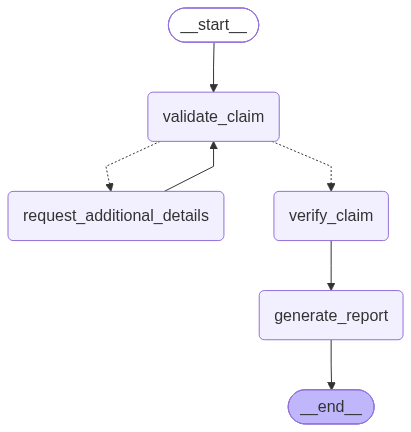

In [24]:
from IPython.display import Image, display

display(
    Image(
        graph.get_graph().draw_mermaid_png()
    )
)

# High-level workflow diagram


                    +----------------------+
                    |   Customer Claim     |
                    +----------+-----------+
                               |
                               v
                    +----------------------+
                    |  Validate Claim Data |
                    +----------+-----------+
                               |
                    Missing Mandatory Fields?
                         /             \
                       Yes             No
                        |               |
                        v               v
            +------------------+   +------------------+
            | Request Missing  |   |   Verify Claim   |
            | Information      |   +--------+---------+
            +--------+---------+            |
                     |                      |
                     +----------+-----------+
                                |
                                v
                    +----------------------+
                    | Generate Final Report|
                    +----------+-----------+
                               |
                               v
                    +----------------------+
                    |         END          |
                    +----------------------+